# 03 — Exploratory Data Analysis

**Goal:** Describe California wildfire activity from 1992–2020: when, where, how big, and under what weather.

We use pandas `groupby()`, `agg()`, `sort_values()` and `value_counts()` to build summary tables,
then plot them. Every chart is saved to `figures/`.

**A note on skew:** most fires are tiny and a few are enormous. Averages get pulled up by the giants,
so we mostly use **medians**, **totals**, or the **share of fires that became large (≥ 100 acres)**.

In [1]:
import sys

import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import numpy as np
import pandas as pd

sys.path.append("../src")
from visualization import set_chart_style, save_figure, format_acres, BLUE, ORANGE, GRAY

set_chart_style()

wildfires = pd.read_csv("../data/processed/wildfires_with_weather.csv", parse_dates=["discovery_date"])
print(wildfires.shape)

(251880, 23)


## 1. How many fires per year?

In [2]:
fires_by_year = wildfires.groupby("fire_year").agg(
    number_of_fires=("fire_id", "count"),
    total_acres=("fire_size_acres", "sum"),
    median_acres=("fire_size_acres", "median"),
    mean_acres=("fire_size_acres", "mean"),
    large_fires=("is_large_fire", "sum"),
)
fires_by_year

,number_of_fires,total_acres,median_acres,mean_acres,large_fires
fire_year,,,,,
1992,10831,296439.600,0.20,27.369550,252
1993,8268,321494.900,0.30,38.884240,207
1994,8649,406965.400,0.30,47.053463,224
1995,7381,216068.700,0.30,29.273635,206
1996,9170,707108.900,0.30,77.111112,361
1997,7928,324565.700,0.20,40.939165,157
1998,6861,160008.500,0.20,23.321455,150
1999,8909,804123.200,0.20,90.259648,231
2000,6970,264670.800,0.20,37.972855,123


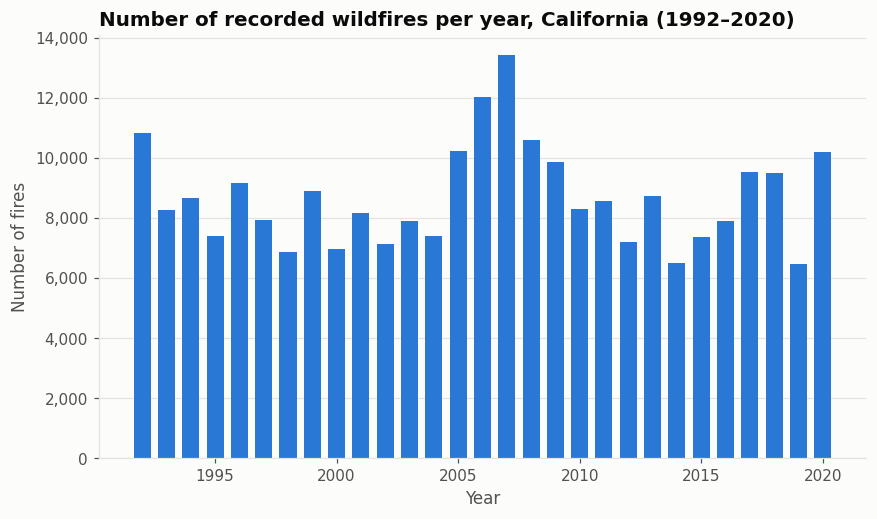

In [3]:
fig, ax = plt.subplots()
ax.bar(fires_by_year.index, fires_by_year["number_of_fires"], color=BLUE, width=0.7)
ax.set_title("Number of recorded wildfires per year, California (1992–2020)")
ax.set_xlabel("Year")
ax.set_ylabel("Number of fires")
ax.yaxis.set_major_formatter(mticker.StrMethodFormatter("{x:,.0f}"))
ax.grid(axis="x", visible=False)
save_figure(fig, "01_fires_by_year.png")
plt.show()

**Caution:** a change in the *number of recorded* fires can reflect changes in reporting, not just in fire activity.
The FPA FOD combines records from many agencies whose reporting systems changed over time.
One visible sign: the median fire size drops from 0.2 to 0.1 acres in 2014–2019, which likely reflects a change
in how small fires were recorded rather than a real change in fires.

## 2. How many acres burned per year?

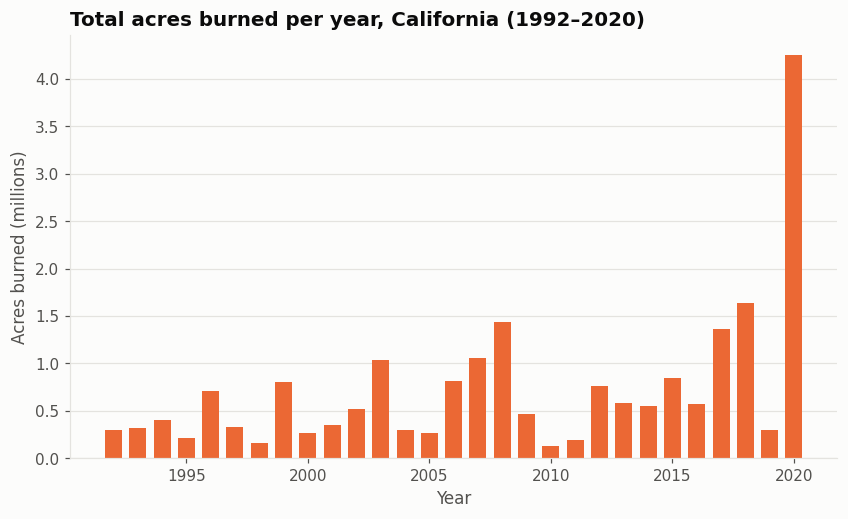

In [4]:
fig, ax = plt.subplots()
ax.bar(fires_by_year.index, fires_by_year["total_acres"] / 1_000_000, color=ORANGE, width=0.7)
ax.set_title("Total acres burned per year, California (1992–2020)")
ax.set_xlabel("Year")
ax.set_ylabel("Acres burned (millions)")
ax.grid(axis="x", visible=False)
save_figure(fig, "02_acres_burned_by_year.png")
plt.show()

In [5]:
fires_by_year.sort_values("total_acres", ascending=False).head(5)[["number_of_fires", "total_acres", "large_fires"]]

,number_of_fires,total_acres,large_fires
fire_year,,,
2020,10198,4253414.89,263
2018,9488,1635757.60,161
2008,10594,1433970.54,296
2017,9537,1360160.00,246
2007,13428,1061554.30,187


Compare the two charts: the **number** of fires and the **area burned** do not move together.
A few years with many very large fires dominate the total area.

## 3. Which months have the most fires?

In [6]:
month_names = ["Jan", "Feb", "Mar", "Apr", "May", "Jun", "Jul", "Aug", "Sep", "Oct", "Nov", "Dec"]

fires_by_month = wildfires.groupby("fire_month").agg(
    number_of_fires=("fire_id", "count"),
    median_acres=("fire_size_acres", "median"),
    total_acres=("fire_size_acres", "sum"),
    share_large=("is_large_fire", "mean"),
)
fires_by_month.index = month_names
fires_by_month

,number_of_fires,median_acres,total_acres,share_large
Jan,4810,0.10,42612.800,0.006029
Feb,4417,0.10,55159.530,0.007245
Mar,5762,0.10,37303.750,0.009198
Apr,11212,0.12,145433.830,0.010257
May,25027,0.25,521277.710,0.017181
Jun,40158,0.30,2310712.901,0.026670
Jul,53011,0.20,4894980.680,0.023976
Aug,41887,0.20,7122837.441,0.029030
Sep,30707,0.20,2678396.360,0.022177
Oct,20178,0.20,2345770.090,0.018684


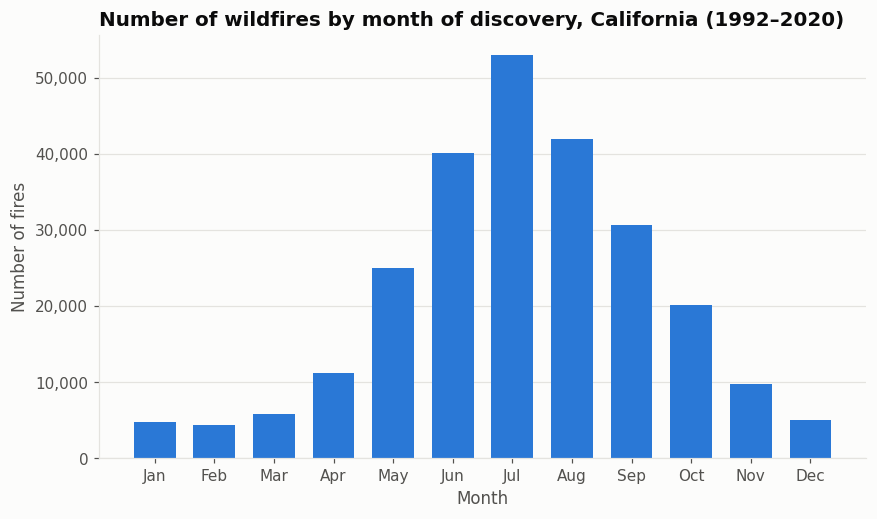

In [7]:
fig, ax = plt.subplots()
ax.bar(fires_by_month.index, fires_by_month["number_of_fires"], color=BLUE, width=0.7)
ax.set_title("Number of wildfires by month of discovery, California (1992–2020)")
ax.set_xlabel("Month")
ax.set_ylabel("Number of fires")
ax.yaxis.set_major_formatter(mticker.StrMethodFormatter("{x:,.0f}"))
ax.grid(axis="x", visible=False)
save_figure(fig, "03_fires_by_month.png")
plt.show()

## 4. In which months are fires largest?

The **median** fire is under an acre in every month (see `median_acres` above), so it doesn't separate months well.
A more informative measure is the **percentage of fires that grew to 100+ acres**.

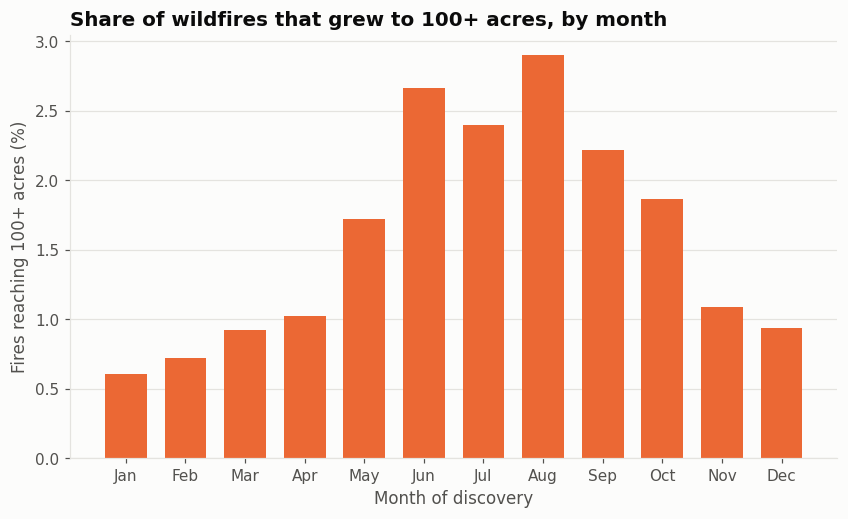

In [8]:
fig, ax = plt.subplots()
ax.bar(fires_by_month.index, fires_by_month["share_large"] * 100, color=ORANGE, width=0.7)
ax.set_title("Share of wildfires that grew to 100+ acres, by month")
ax.set_xlabel("Month of discovery")
ax.set_ylabel("Fires reaching 100+ acres (%)")
ax.grid(axis="x", visible=False)
save_figure(fig, "04_share_large_by_month.png")
plt.show()

## 5. The distribution of fire sizes

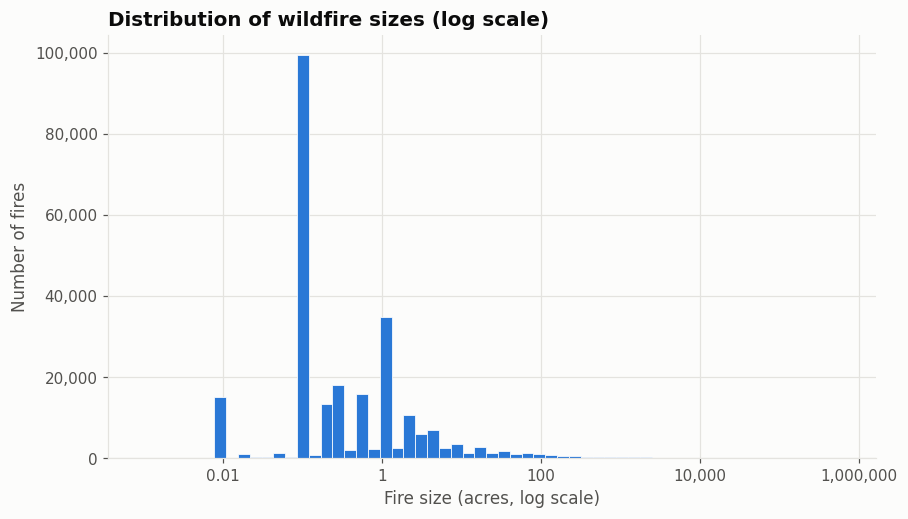

In [9]:
fig, ax = plt.subplots()
bins = np.logspace(np.log10(wildfires["fire_size_acres"].min()), np.log10(wildfires["fire_size_acres"].max()), 60)
ax.hist(wildfires["fire_size_acres"], bins=bins, color=BLUE, edgecolor="white", linewidth=0.5)
ax.set_xscale("log")
ax.set_title("Distribution of wildfire sizes (log scale)")
ax.set_xlabel("Fire size (acres, log scale)")
ax.set_ylabel("Number of fires")
ax.xaxis.set_major_formatter(mticker.FuncFormatter(format_acres))
ax.yaxis.set_major_formatter(mticker.StrMethodFormatter("{x:,.0f}"))
save_figure(fig, "05_fire_size_distribution.png")
plt.show()

We used a **log scale** on the x-axis because sizes range from 0.001 to ~589,000 acres. On a normal scale,
every bar except the first would be invisible.

**Why is the histogram so spiky?** Small fires are usually reported as rounded numbers (0.01, 0.1, 0.25, 1 acre),
so many fires share exactly the same size. That's a feature of how the data was recorded, not an error,
but it means the exact size of very small fires is imprecise.

In [10]:
wildfires["fire_size_acres"].describe(percentiles=[0.5, 0.9, 0.99, 0.999]).round(2)

count    251880.00
mean         83.08
std        3039.46
min           0.00
50%           0.20
90%           5.00
99%         363.13
99.9%     14004.72
max      589368.00
Name: fire_size_acres, dtype: float64

## 6. The largest fires in the dataset

In [11]:
wildfires.sort_values("fire_size_acres", ascending=False).head(10)[
    ["fire_name", "discovery_date", "county", "fire_size_acres", "cause",
     "temp_max_f", "relative_humidity", "wind_speed_mph"]
]

,fire_name,discovery_date,county,fire_size_acres,cause,temp_max_f,relative_humidity,wind_speed_mph
251149,DOE,2020-08-16,Glenn,589368.0,Natural,106.934,20.14,3.511996
207047,RANCH,2018-07-28,Mendocino,410203.0,Equipment and vehicle use,90.968,32.15,0.917145
251118,SCU LIGHTNING COMPLEX,2020-08-16,Santa Clara,396624.0,Missing data/not specified/undetermined,107.780,34.57,4.675205
250926,CREEK,2020-09-04,Fresno,379895.0,Missing data/not specified/undetermined,97.970,23.41,1.655336
251192,HOPKINS,2020-08-17,Trinity,328363.0,Natural,90.266,34.42,0.223694
251019,CLAREMONT,2020-08-17,Plumas,318776.0,Natural,94.298,40.03,0.917145
155631,RUSH,2012-08-12,Lassen,315578.8,Natural,98.204,16.60,2.661959
251216,HENNESSEY,2020-08-17,Napa,305651.2,Natural,99.824,33.44,3.310671
190731,THOMAS,2017-12-04,Ventura,281893.0,Missing data/not specified/undetermined,59.972,24.24,9.305670
31036,CEDAR,2003-10-25,Unknown,280059.0,Recreation and ceremony,91.724,25.59,3.914645


## 7. Which counties have the most fire activity?

Remember: county is missing for ~38% of records ("Unknown"). We exclude "Unknown" from these rankings,
so the counts are **lower bounds**, and counties whose agencies left county blank more often are under-counted.

In [12]:
known_county = wildfires[wildfires["county"] != "Unknown"]

counties = known_county.groupby("county").agg(
    number_of_fires=("fire_id", "count"),
    total_acres=("fire_size_acres", "sum"),
)
top_by_count = counties.sort_values("number_of_fires", ascending=False).head(15)
top_by_acres = counties.sort_values("total_acres", ascending=False).head(15)
top_by_count

,number_of_fires,total_acres
county,,
Riverside,17159,393380.37
Los Angeles,9584,677248.59
Fresno,8236,766340.36
San Bernardino,7475,372923.26
San Diego,6648,593109.47
Merced,5305,77561.61
El Dorado,5003,126232.98
Butte,4981,337177.78
Madera,4945,85167.48


In [13]:
top_by_acres

,number_of_fires,total_acres
county,,
Siskiyou,3973,1073630.01
Trinity,1768,959923.58
Fresno,8236,766340.36
Los Angeles,9584,677248.59
Shasta,4734,663357.95
Lassen,2509,661998.45
Monterey,2367,650154.99
Plumas,1667,643513.15
Glenn,174,621387.84


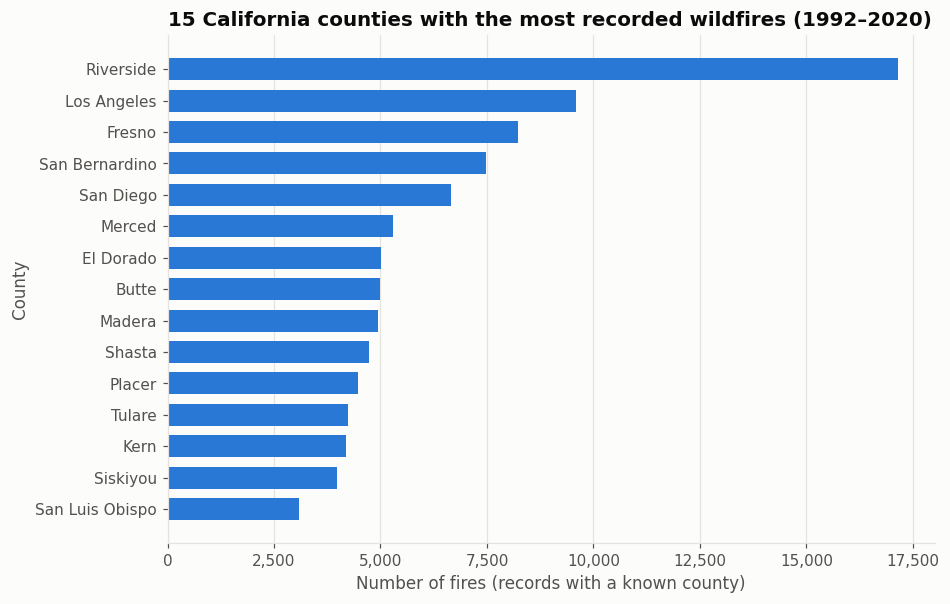

In [14]:
fig, ax = plt.subplots(figsize=(9, 6))
plot_data = top_by_count.sort_values("number_of_fires")
ax.barh(plot_data.index, plot_data["number_of_fires"], color=BLUE, height=0.7)
ax.set_title("15 California counties with the most recorded wildfires (1992–2020)")
ax.set_xlabel("Number of fires (records with a known county)")
ax.set_ylabel("County")
ax.xaxis.set_major_formatter(mticker.StrMethodFormatter("{x:,.0f}"))
ax.grid(axis="y", visible=False)
save_figure(fig, "06_top_counties_by_fires.png")
plt.show()

## 8. Where are the fires? (map)

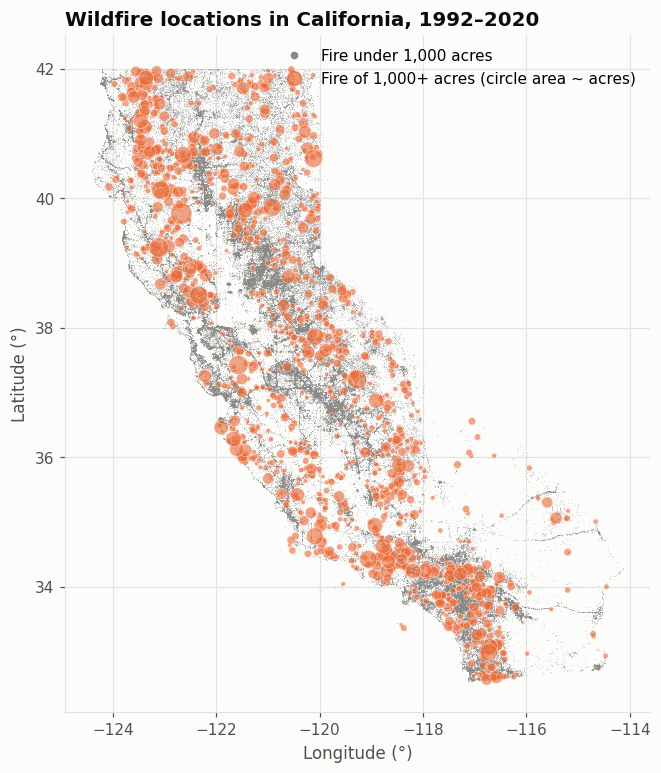

In [15]:
fig, ax = plt.subplots(figsize=(7, 8))
small = wildfires[wildfires["fire_size_acres"] < 1000]
big = wildfires[wildfires["fire_size_acres"] >= 1000].sort_values("fire_size_acres")

ax.scatter(small["longitude"], small["latitude"], s=0.3, color=GRAY, alpha=0.25, linewidths=0,
           label="Fires under 1,000 acres")
ax.scatter(big["longitude"], big["latitude"], s=np.sqrt(big["fire_size_acres"]) / 4, color=ORANGE,
           alpha=0.6, edgecolor="white", linewidth=0.4, label="Fires of 1,000+ acres (size ~ area)")
ax.set_title("Wildfire locations in California, 1992–2020")
ax.set_xlabel("Longitude (°)")
ax.set_ylabel("Latitude (°)")
ax.set_aspect(1 / np.cos(np.radians(37)))  # keeps California's shape from looking stretched
from matplotlib.lines import Line2D
legend_items = [
    Line2D([], [], marker="o", linestyle="", color=GRAY, markersize=4, label="Fire under 1,000 acres"),
    Line2D([], [], marker="o", linestyle="", color=ORANGE, markersize=9, alpha=0.7,
           label="Fire of 1,000+ acres (circle area ~ acres)"),
]
ax.legend(handles=legend_items, loc="upper right")
save_figure(fig, "07_wildfire_map.png")
plt.show()

No map background is drawn, but the outline of California appears on its own from the fire points.

## 9. Weather on the day fires were discovered

In [16]:
weather_columns = ["temp_max_f", "relative_humidity", "wind_speed_mph", "precip_mm", "precip_prev_7day_mm"]
wildfires[weather_columns].describe().round(1)

,temp_max_f,relative_humidity,wind_speed_mph,precip_mm,precip_prev_7day_mm
count,251880.0,251880.0,251880.0,251880.0,251880.0
mean,83.3,45.2,3.8,0.4,2.4
std,13.7,18.6,2.3,1.8,7.6
min,19.0,6.1,0.0,0.0,0.0
25%,73.9,30.2,2.2,0.0,0.0
50%,84.7,42.9,3.6,0.0,0.2
75%,93.7,58.7,5.1,0.1,1.5
max,120.2,100.0,27.9,102.8,470.2


In [17]:
wildfires.groupby("is_large_fire")[weather_columns].median().round(1)

,temp_max_f,relative_humidity,wind_speed_mph,precip_mm,precip_prev_7day_mm
is_large_fire,,,,,
False,84.6,43.1,3.6,0.0,0.2
True,89.9,34.4,3.9,0.0,0.1


The table above compares the **median** weather on the discovery day for fires that stayed under 100 acres (`False`)
versus fires that grew to 100+ acres (`True`).

## 10. Weather vs. fire size

Plotting all ~250,000 fires would be a solid blob, so each panel shows a **random sample of 5,000 fires**
(light dots) with a **log-scale y-axis**, plus a line for the **median fire size** in each tenth (decile) of the weather variable.

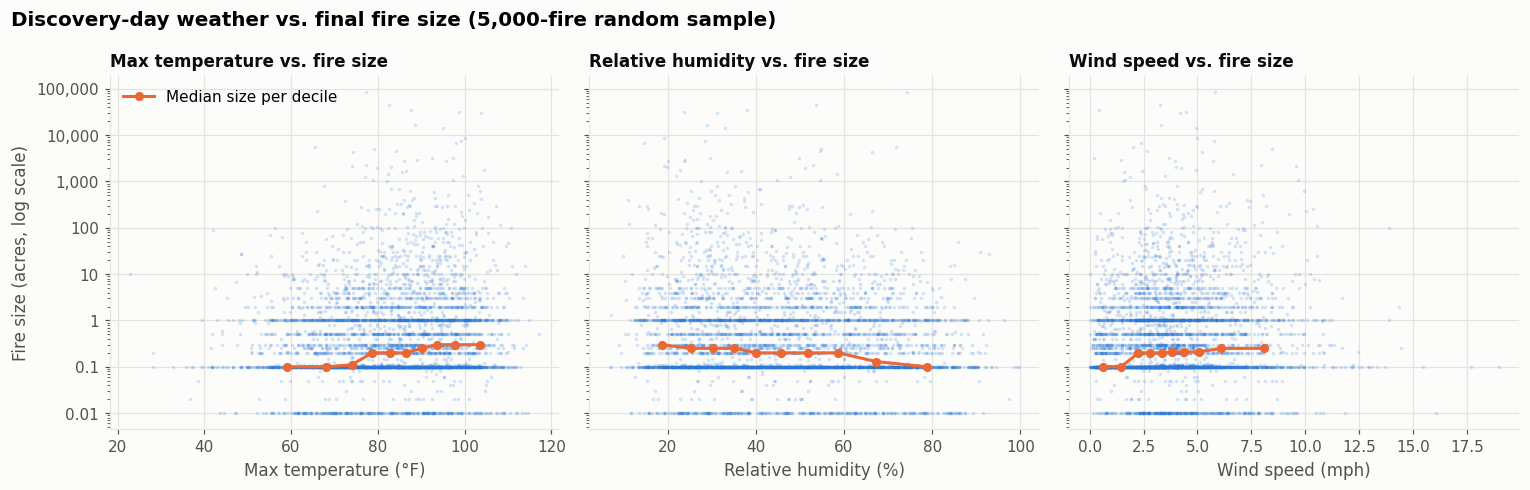

In [18]:
sample = wildfires.dropna(subset=weather_columns).sample(5000, random_state=42)

panels = [
    ("temp_max_f", "Max temperature (°F)"),
    ("relative_humidity", "Relative humidity (%)"),
    ("wind_speed_mph", "Wind speed (mph)"),
]

fig, axes = plt.subplots(1, 3, figsize=(14, 4.5), sharey=True)
for ax, (column, label) in zip(axes, panels):
    ax.scatter(sample[column], sample["fire_size_acres"], s=5, color=BLUE, alpha=0.2, linewidths=0)

    deciles = pd.qcut(wildfires[column], 10, duplicates="drop")
    decile_summary = wildfires.groupby(deciles, observed=True).agg(
        x=(column, "median"), median_acres=("fire_size_acres", "median"))
    ax.plot(decile_summary["x"], decile_summary["median_acres"], color=ORANGE, linewidth=2,
            marker="o", markersize=5, label="Median size per decile")

    ax.set_yscale("log")
    ax.set_xlabel(label)
    ax.set_title(label.split(" (")[0] + " vs. fire size", fontsize=11)
axes[0].set_ylabel("Fire size (acres, log scale)")
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(format_acres))
axes[0].legend(loc="upper left")
fig.suptitle("Discovery-day weather vs. final fire size (5,000-fire random sample)", x=0.01, ha="left",
             fontweight="bold", fontsize=13)
fig.tight_layout()
save_figure(fig, "08_weather_vs_fire_size.png")
plt.show()

The horizontal lines of dots at 0.1 and 1 acre are the same rounding effect seen in the histogram.

**How to read this:** if hotter days produced bigger fires, the orange line would slope upward in the left panel.
The scatter shows huge variation at every temperature, humidity, and wind level: most fires on even the hottest,
driest days stay small. We measure these relationships with numbers in Notebook 04.